## Bayes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal as mvm

## Import Data

In [2]:
df = pd.read_csv('../../dataset/day18/exNB.csv',header=None)

In [3]:
df.head()

,0,1,2
0,75.626754,181.704486,1.0
1,70.540408,176.177640,1.0
2,76.875023,178.667364,1.0
3,70.225610,157.504877,1.0
4,74.106298,168.525499,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       1000 non-null   float64
 1   1       1000 non-null   float64
 2   2       1000 non-null   float64
dtypes: float64(3)
memory usage: 23.6 KB


In [5]:
df.describe()

,0,1,2
count,1000.000000,1000.000000,1000.00000
mean,68.155256,160.017547,0.50000
std,4.244282,22.154977,0.50025
min,55.166637,114.656690,0.00000
25%,65.231987,140.252109,0.00000
50%,67.949412,156.189017,0.50000
75%,70.654700,179.735810,1.00000
max,86.953858,207.860094,1.00000


In [6]:
X = df.to_numpy()
X

array([[ 75.62675441, 181.70448626,   1.        ],
       [ 70.54040833, 176.17763989,   1.        ],
       [ 76.87502316, 178.66736388,   1.        ],
       ...,
       [ 65.34582701, 135.19952982,   0.        ],
       [ 59.38533074, 152.59859562,   0.        ],
       [ 68.708487  , 129.95783574,   0.        ]], shape=(1000, 3))

In [7]:
y = X[:,2]
y

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1.

In [8]:
X = X[:,:2]
X

array([[ 75.62675441, 181.70448626],
       [ 70.54040833, 176.17763989],
       [ 76.87502316, 178.66736388],
       ...,
       [ 65.34582701, 135.19952982],
       [ 59.38533074, 152.59859562],
       [ 68.708487  , 129.95783574]], shape=(1000, 2))

In [9]:
print(f"X : {X.shape}, \t y : {y.shape}")

X : (1000, 2), 	 y : (1000,)


## Data Visualization

In [10]:
#Boolean Indexing
len(X[y==0,0])

500

In [11]:
y==0

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

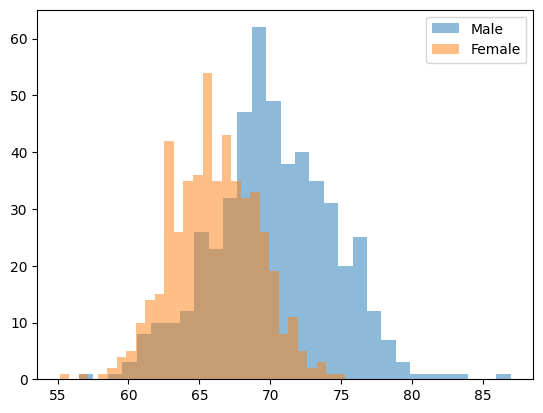

In [12]:
plt.figure()
plt.hist(X[y==1,0], label='Male', alpha=0.5, bins=30)
plt.hist(X[y==0,0], label='Female', alpha=0.5, bins=30)
plt.legend()
plt.show()

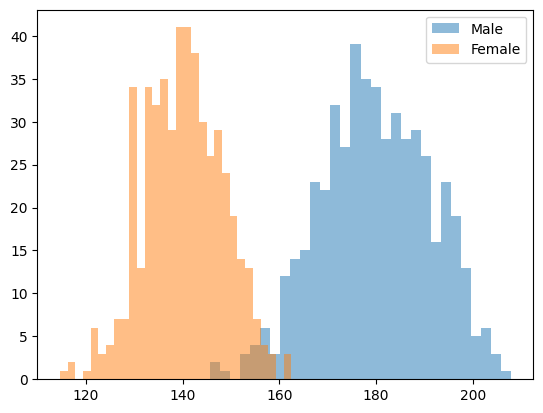

In [13]:
plt.figure()
plt.hist(X[y==1,1], label='Male', alpha=0.5, bins=30)
plt.hist(X[y==0,1], label='Female', alpha=0.5, bins=30)
plt.legend()
plt.show()

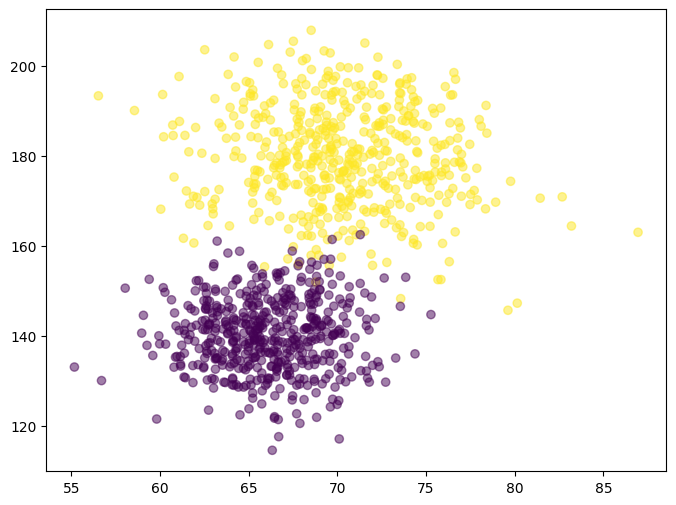

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(X[:,0],X[:,1], c=y, alpha=0.5)

## Naive Bayes' Classifer

In [15]:
class GaussNB():

    def fit(self, X, y, epsilon = 1e-3):

        self.likelihood = dict()
        self.priors = dict()
        self.K = set(y.astype(int))

        for k in self.K:
            
            X_k = X[y==k]
            self.likelihood[k] = {"mean": X_k.mean(axis=0),"cov":X_k.var(axis=0)+epsilon}
            self.priors[k] = len(X_k)/len(X)
    
    def predict(self, X):
        N, D = X.shape
        P_hat = np.zeros((N,len(self.K)))

        for k, l in self.likelihood.items():
            P_hat[:,k] = mvm.logpdf(X,l['mean'],l['cov'])+np.log(self.priors[k])

        return P_hat.argmax(axis=1)


In [16]:
def accuracy(y, y_hat):
    return np.mean(y==y_hat)

In [17]:
gnb = GaussNB()

In [18]:
gnb.fit(X,y)

In [19]:
y_hat = gnb.predict(X)

In [20]:
acc = accuracy(y,y_hat)
acc

np.float64(0.988)

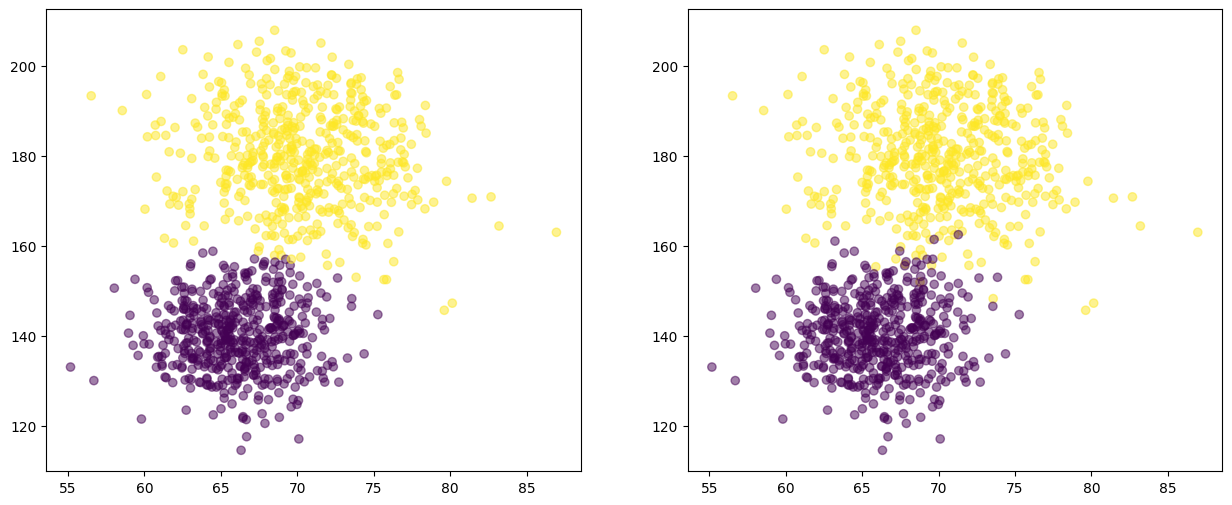

In [21]:
fig = plt.figure(figsize=(40,6))
ax1 = fig.add_subplot(1,5,1)
ax1.scatter(X[:,0],X[:,1], c=y_hat, alpha=0.5)
ax2 = fig.add_subplot(1,5,2)
ax2.scatter(X[:,0],X[:,1], c=y, alpha=0.5)
plt.show()

In [22]:
def CoinFlip(y):
  y_hat=np.zeros(len(y))
  for i in range(len(y)):
    flip = np.random.randn(1)
    if flip >0:
      y_hat[i]=1
  return y_hat

In [23]:
acc = accuracy(y,CoinFlip(y))
acc

np.float64(0.499)

In [24]:
df2 = pd.read_csv('../../dataset/day18/xor.csv')    

In [25]:
df2.head()
df2['y'].unique()   

array([0, 1])

In [26]:
X2 = df2.to_numpy()
X2

array([[ 1.90756726,  0.32586513,  0.        ],
       [ 2.27054368,  2.25881652,  0.        ],
       [ 2.32308573,  1.46660143,  0.        ],
       ...,
       [ 3.0596909 , -2.87353245,  1.        ],
       [ 3.52560718, -2.33106954,  1.        ],
       [ 1.72005898, -1.13464011,  1.        ]], shape=(4000, 3))

In [27]:
y2 = X2[:,2]
X2 = X2[:,:2]

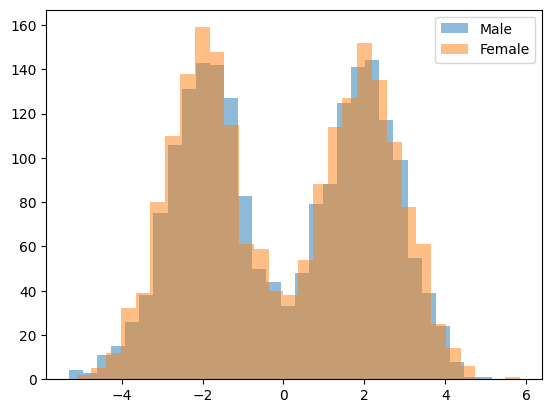

In [28]:
plt.figure()
plt.hist(X2[y2==1,0], label='Male', alpha=0.5, bins=30)
plt.hist(X2[y2==0,0], label='Female', alpha=0.5, bins=30)
plt.legend()
plt.show()

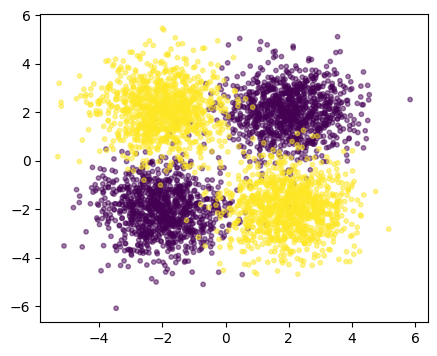

In [29]:
plt.figure(figsize=(5,4))
plt.scatter(X2[:,0],X2[:,1], c=y2, alpha=0.5, s=10)

In [30]:
xor_gnb = GaussNB()
xor_gnb.fit(X2,y2)
y2_hat = xor_gnb.predict(X2)
acc2 = accuracy(y2,y2_hat)
acc2

np.float64(0.51275)

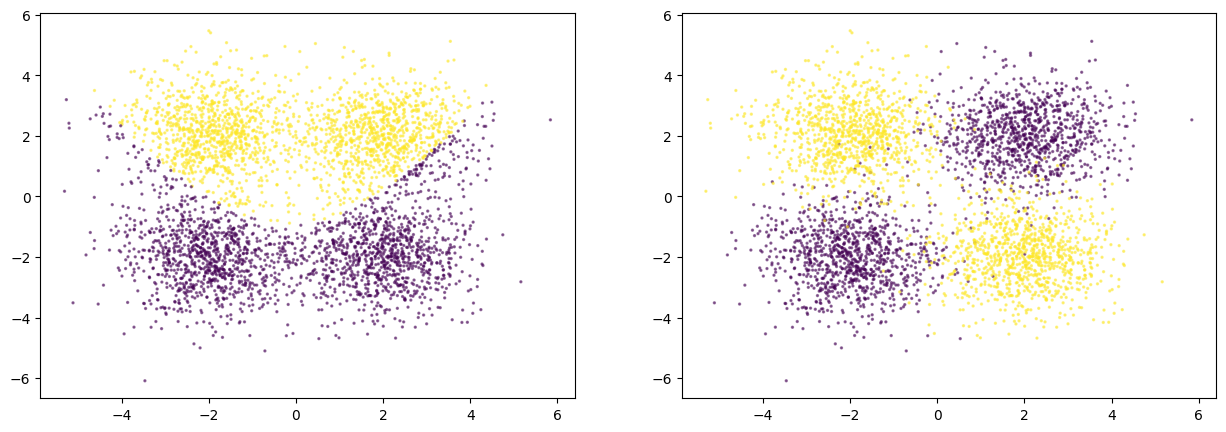

In [31]:
fig = plt.figure(figsize=(40,5))
ax1 = fig.add_subplot(1,5,1)
ax1.scatter(X2[:,0],X2[:,1], c=y2_hat, alpha=0.5,s=2)
ax2 = fig.add_subplot(1,5,2)
ax2.scatter(X2[:,0],X2[:,1], c=y2, alpha=0.5, s=2)
plt.show()

## Non-Naive Bayes Classifier

In [32]:
class GaussBayes():

    def fit(self,X,y,epsilon=1e-3):
        self.likelihood = dict()
        self.priors = dict()

        self.K = set(y.astype(int))

        for k in self.K:
            X_k = X[y==k,:]
            N_k, D = X_k.shape
            mu_k = X_k.mean(axis=0)

            self.likelihood[k] = {'mean':X_k.mean(axis=0),
                                  'cov': (1/N_k) * np.matmul((X_k - mu_k).T, (X_k - mu_k)) + epsilon*np.identity(D)}
            self.priors[k] = len(X_k)/len(X)
    
    def predict(self, X):
        N, D = X.shape
        P_hat = np.zeros((N,len(self.K)))

        for k, l in self.likelihood.items():
            P_hat[:,k] = mvm.logpdf(X,l['mean'],l['cov'])+np.log(self.priors[k])

        return P_hat.argmax(axis=1)

In [33]:
gauss_bayes_classifier = GaussBayes()
gauss_bayes_classifier.fit(X2,y2)
y2_hat = gauss_bayes_classifier.predict(X2)
acc = accuracy(y2,y2_hat)
acc

np.float64(0.95825)

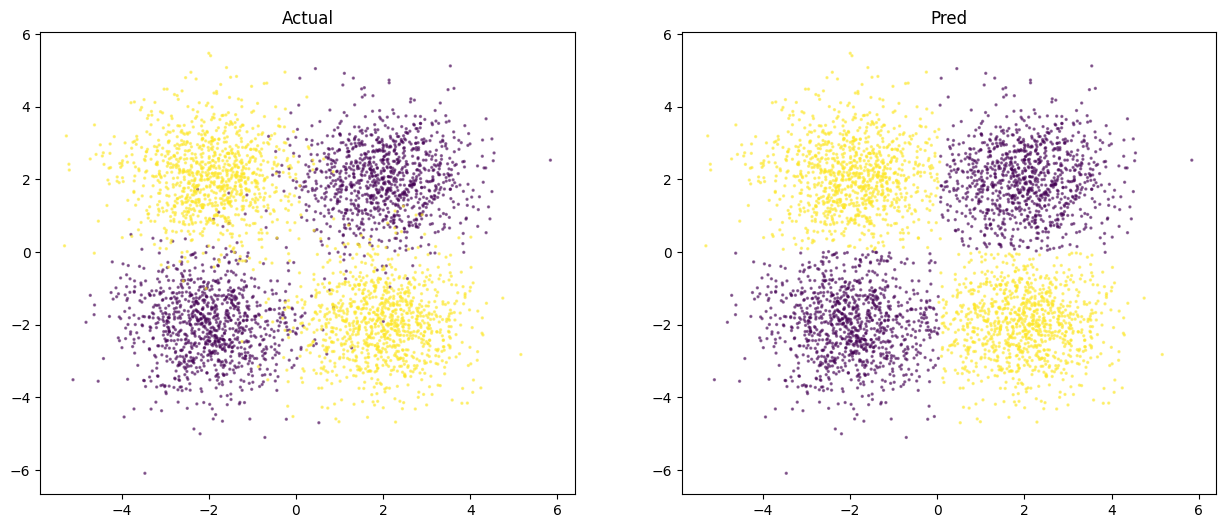

In [50]:

fig = plt.figure(figsize=(40,6))
ax1 = fig.add_subplot(1,5,1)
ax1.scatter(X2[:,0],X2[:,1], c=y2, alpha=0.5,s=2)
plt.title("Actual")
ax2 = fig.add_subplot(1,5,2)
ax2.scatter(X2[:,0],X2[:,1], c=y2_hat, alpha=0.5, s=2)
plt.title("Pred")
plt.show()